# Step size scheduling

The following is a discussion on step sizes within the IAS15 integrator. It does not apply to fixed step sizes integrators like any of the built-in symplectic leapfrog schemes.

The "A" in IAS15 stands for "adaptive", meaning the integrator is allowed to choose and change its step size as it evolves the system. To set up this adaptation, we must first make two choices:

1. Do we want to take a step that lands exactly on every requested output time, or do we want to allow the integrator to take "natural" steps until it passes the latest requested output time, then to "interpolate" among the outputs to solve the positions and velocities at arbitrary intermediate times? Here we don't mean "interpolate" in the usual sense where we lose information while guessing a trajectory between known locations. As described in the [IAS15 paper](https://scixplorer.org/abs/2015MNRAS.446.1424R/abstract), the integrator evaluates positions and velocities by first running a predictor-corrector loop to solve for a 7th-order polynomial approximation of the acceleration within one time step, then integrates this polynomial using Gauss-Radau quadrature to get the positions and velocities at the end of the step. But, if we instead evaluate that same integral at a slightly earlier sub-step time, we can recreate the positions and velocities at that time with no* loss of information (TODO: figure out if we actually do lose information since we aren't using the Gauss-Radau nodes when we evaluate the integral at arbitrary H values.) This choice is the difference between `integrate` and `integrate_or_interpolate` in both the `REBOUND` and `jorbit` APIs (TODO: finish actually implementing this API in `jorbit`, replace all the bits about forced_landing)
   
2. Regardless if we're willing to overshoot and interpolate or not, how do we define a "natural" step size? There are two candidate algorithms for this. The ["PRS23" algorithm](https://scixplorer.org/abs/2024OJAp....7E...1P/abstract) from Pham+ 2023, which is the default in `jorbit` and has been the default in `REBOUND` since 2024, and the "global" step size controller from the original `IAS15` paper.

That leaves us with four possible combinations of step size scheduling:
| Step size scheduling | Output times |
|----------------------|--------------|
| PRS23                | Forced landing |
| PRS23                | Interpolation |
| Global               | Forced landing |
| Global               | Interpolation |

Here's what these four options look like using both codes:

In [1]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import pprint
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time

from jplephem.spk import SPK

import rebound
import assist
from rebound import Particle as rebound_Particle

from jorbit import Particle
from jorbit.accelerations import (
    create_default_ephemeris_acceleration_func,
    create_newtonian_ephemeris_acceleration_func,
    create_ephem_grav_harmonics_acceleration_func,
    nongrav_acceleration,
)
from jorbit.data.constants import (
    EARTH_J_HARMONICS,
    EARTH_RADIUS,
    SPEED_OF_LIGHT,
    SUN_J_HARMONICS,
    SUN_RADIUS,
)
from jorbit.ephemeris import Ephemeris, EphemerisProcessor
from jorbit.utils.horizons import horizons_bulk_vector_query
from jorbit.utils.states import CartesianState, SystemState, KeplerianState

times = Time(
    np.linspace(Time("2029-01-01").tdb.jd, Time("2030-01-01").tdb.jd, 1000),
    format="jd",
    scale="tdb",
)
# change these to your local path- jorbit doesn't store these files, see ASSIST docs for more
ephem = assist.Ephem(
    "/Users/cassese/Downloads/linux_p1550p2650.440",
    "/Users/cassese/Downloads/sb441-n16.bsp",
)

# get the Sun's position and velocity from the usual jorbit interface-
# the Apophis SPK's are relative to the Sun, not the solar system barycenter
usual_eph = Ephemeris(ssos="default solar system")
eph_state = usual_eph.state(times)
sun_xs = eph_state["sun"]["x"].value
sun_vs = eph_state["sun"]["v"].value
earth_xs = eph_state["earth"]["x"].value
earth_vs = eph_state["earth"]["v"].value


def parse_apophis_file(filename):

    # open ephemeris
    spk = SPK.open(filename)
    starts = np.array([seg.start_jd for seg in spk.segments])
    ends = np.array([seg.end_jd for seg in spk.segments])
    order = starts.argsort()
    starts = jnp.array(starts[order])
    ends = jnp.array(ends[order])

    # create a list of EphemerisProcessor objects for each segment
    processors = []
    for ind in order:
        init, intlen, coeff = spk.segments[ind]._data
        processors.append(
            EphemerisProcessor(
                jnp.array([init]),
                jnp.array([intlen]),
                jnp.array([coeff]),
                jnp.array([0.0]),
            )
        )

    # figure out which processor to use for each time
    processor_inds = jnp.searchsorted(starts, times.tdb.jd) - 1

    # query those processors for the state of Apophis, then subtract off the sun's position
    helio_xs = np.zeros((len(processor_inds), 3))
    helio_vs = np.zeros((len(processor_inds), 3))
    for i, (ind, t) in enumerate(zip(processor_inds, times.tdb.jd)):
        _x, _v = processors[ind].state(t)
        helio_xs[i] = _x[0]
        helio_vs[i] = _v[0]
    final_xs = helio_xs + sun_xs
    final_vs = helio_vs + sun_vs

    return jnp.array(final_xs), jnp.array(final_vs)


jpl_220_xs, jpl_220_vs = parse_apophis_file("../../paper/data/sb-99942-220.bsp")

In [2]:
x0 = jpl_220_xs[0]
v0 = jpl_220_vs[0]


def assist_sim(scheduler, interpolate):
    apophis_initial = rebound_Particle(
        x=x0[0],
        y=x0[1],
        z=x0[2],
        vx=v0[0],
        vy=v0[1],
        vz=v0[2],
    )

    sim = rebound.Simulation()
    sim.add(apophis_initial)
    sim.t = times[0].tdb.jd - ephem.jd_ref
    sim.ri_ias15.min_dt = 0.001
    extras = assist.Extras(sim, ephem)
    sim.ri_ias15.adaptive_mode = scheduler

    # Turn on GR for star and all planets
    extras.gr_eih_sources = 11

    # Add the nongravitational forces (values specific to Apophis from the Horizons solution)
    extras.particle_params = np.array([4.999999873689e-13, -2.901085508711e-14, 0.0])

    assist_xs = np.zeros((len(times), 3))
    assist_vs = np.zeros((len(times), 3))
    for i, t in enumerate(times):
        if interpolate:
            extras.integrate_or_interpolate(t.tdb.jd - ephem.jd_ref)
        else:
            sim.integrate(t.tdb.jd - ephem.jd_ref)
        assist_xs[i] = sim.particles[0].xyz
        assist_vs[i] = sim.particles[0].vxyz
    return assist_xs, assist_vs, sim.steps_done


assist_results = {}
for scheduler in ["prs23", "global"]:
    for interpolate in [False, True]:
        x, v, s = assist_sim(scheduler, interpolate)
        assist_results[(scheduler, interpolate)] = (x, v, s)

In [3]:
# construct each component of the acceleration function piece-by-piece

# first, just the usual gravitational acceleration function, GR for planets, newtonian for asteroids
eph = Ephemeris(ssos="default solar system")
acc_func_grav = create_default_ephemeris_acceleration_func(
    ephem_processor=eph.processor
)

# add the J harmonics for the Sun and Earth
acc_func_solar_harmonics = create_ephem_grav_harmonics_acceleration_func(
    eph.processor, ephem_index=0, state_index=0
)
acc_func_earth_harmonics = create_ephem_grav_harmonics_acceleration_func(
    eph.processor, ephem_index=3, state_index=1
)


# combine those 3, along with the non-gravitational forces
# (which didn't need to be created separately since it just relies on SystemState)
def _acc_func(state: SystemState) -> jnp.ndarray:
    return (
        acc_func_grav(state)
        + nongrav_acceleration(state)
        + acc_func_solar_harmonics(state)
        + acc_func_earth_harmonics(state)
    )


acc_func = jax.tree_util.Partial(_acc_func)

# set the J coefficients
js = jnp.zeros((2, 3))
js = js.at[0, 0].set(SUN_J_HARMONICS[0])
js = js.at[1].set(EARTH_J_HARMONICS)

acceleration_func_kwargs = {
    "c2": SPEED_OF_LIGHT**2,
    "a1": jnp.array([4.999999873689e-13]),  # the same non-grav coefficients
    "a2": jnp.array([-2.901085508711e-14]),
    "a3": jnp.array([0.0]),
    "js_req": jnp.array([SUN_RADIUS, EARTH_RADIUS]),
    "js_pole_ra": jnp.array(
        [286.13 * jnp.pi / 180, 359.99868 * jnp.pi / 180]
    ),  # the RA and Dec of the poles in April 2029
    "js_pole_dec": jnp.array([63.87 * jnp.pi / 180, 89.83523 * jnp.pi / 180]),
    "js": js,
}

c = CartesianState(
    x=jnp.array([jpl_220_xs[0]]),
    v=jnp.array([jpl_220_vs[0]]),
    time=times[0].tdb.jd,
    acceleration_func_kwargs=acceleration_func_kwargs,
)

p = Particle(state=c, gravity=acc_func)

jorb_results = {}
for scheduler in ["prs23", "global"]:
    for interpolate in [False, True]:
        if interpolate:
            xs, vs, steps = p.integrate_or_interpolate(times, step_scheduler=scheduler)
        else:
            xs, vs, steps = p.integrate(times, step_scheduler=scheduler)
        xs.block_until_ready()
        jorb_results[(scheduler, interpolate)] = (xs, vs, steps)

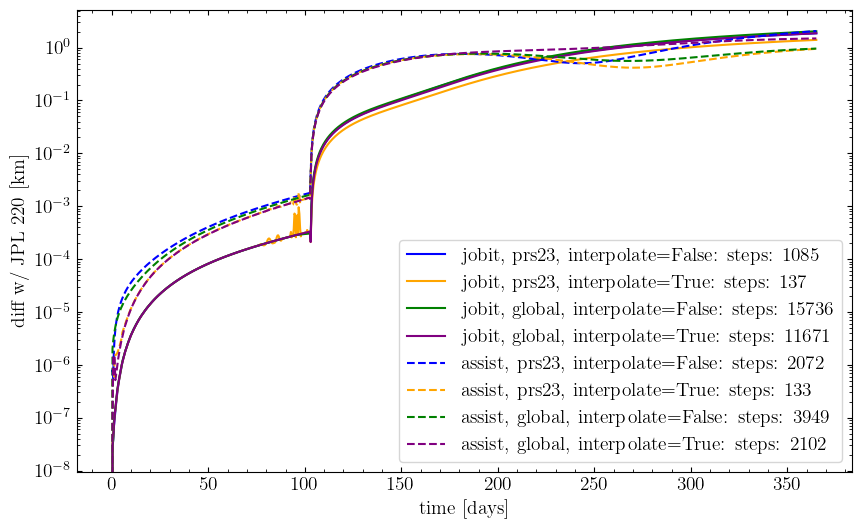

In [4]:
colors = ["blue", "orange", "green", "purple"]
fig, ax = plt.subplots(figsize=(10, 6))
for i, ((scheduler, interpolate), (xs, vs, steps)) in enumerate(jorb_results.items()):
    label = f"jobit, {scheduler}, interpolate={interpolate}: steps: {steps}"
    ax.plot(
        times.mjd - times.mjd[0],
        jnp.linalg.norm(xs - jpl_220_xs, axis=1) * u.au.to(u.km),
        color=colors[i],
        label=label,
    )


for i, ((scheduler, interpolate), (xs, vs, steps)) in enumerate(assist_results.items()):
    label = f"assist, {scheduler}, interpolate={interpolate}: steps: {steps}"
    ax.plot(
        times.mjd - times.mjd[0],
        jnp.linalg.norm(xs - jpl_220_xs, axis=1) * u.au.to(u.km),
        label=label,
        color=colors[i],
        linestyle="dashed",
    )

ax.set(
    yscale="log",
    xlabel="time [days]",
    ylabel="diff w/ JPL 220 [km]",
)

ax.legend()